# Day 36 (1/2) — Lasso Regression: The Feature Selector

### Yesterday vs today
**Ridge** shrinks *every* weight a little: it **never removes** a feature.

But real datasets are full of features that do not matter. What if the model could **switch them off by itself**?

**Lasso** does exactly that. Change one symbol in the penalty, $w^2 \rightarrow |w|$, and weights start hitting **exactly zero**.

### In this notebook
1. ✏️ The one-symbol change
2. 📉 A slope that actually reaches zero
3. 🏥 Lasso picks the important diabetes features for you
4. 🌊 Lasso on a wiggly polynomial

> 📖 Theory: [`theory.md`](theory.md) · 🎨 *Visualization only* cells are collapsed: you only need their plots.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
plt.rcParams.update({'figure.dpi': 100, 'axes.grid': True, 'grid.alpha': 0.3,
                     'axes.spines.top': False, 'axes.spines.right': False})

---
## 1. ✏️ The one-symbol change

| | Penalty | Name |
|---|---|---|
| Ridge | $\alpha \sum w_j^2$ | L2 |
| **Lasso** | $\alpha \sum \lvert w_j \rvert$ | **L1** |

**Lasso** = *Least Absolute Shrinkage and Selection Operator*. The name says it all: it **shrinks** weights and
**selects** features.

---
## 2. 📉 A slope that actually reaches zero

> ✍️ **Core code: learn this.** Lasso has the same API as Ridge.

In [2]:
from sklearn.datasets import make_regression

X1, y1 = make_regression(n_samples=100, n_features=1, noise=20, random_state=13)

print(f"LinearRegression  slope = {LinearRegression().fit(X1, y1).coef_[0]:6.2f}")
for alpha in [1, 10, 20, 30]:
    model = Lasso(alpha=alpha).fit(X1, y1)
    print(f"Lasso alpha = {alpha:<3}  slope = {model.coef_[0]:6.2f}")

LinearRegression  slope =  27.83
Lasso alpha = 1    slope =  26.68
Lasso alpha = 10   slope =  16.31
Lasso alpha = 20   slope =   4.80
Lasso alpha = 30   slope =   0.00


At α = 30 the slope is **exactly 0.00**: the feature has been switched off and the model is a flat line at the mean.
Now compare how Ridge and Lasso approach zero:

> 🎨 **Visualization only. You do not need to learn this code.** It just draws the picture below. Run it and focus on the plot. *(The code is collapsed; click it to expand if you are curious.)*

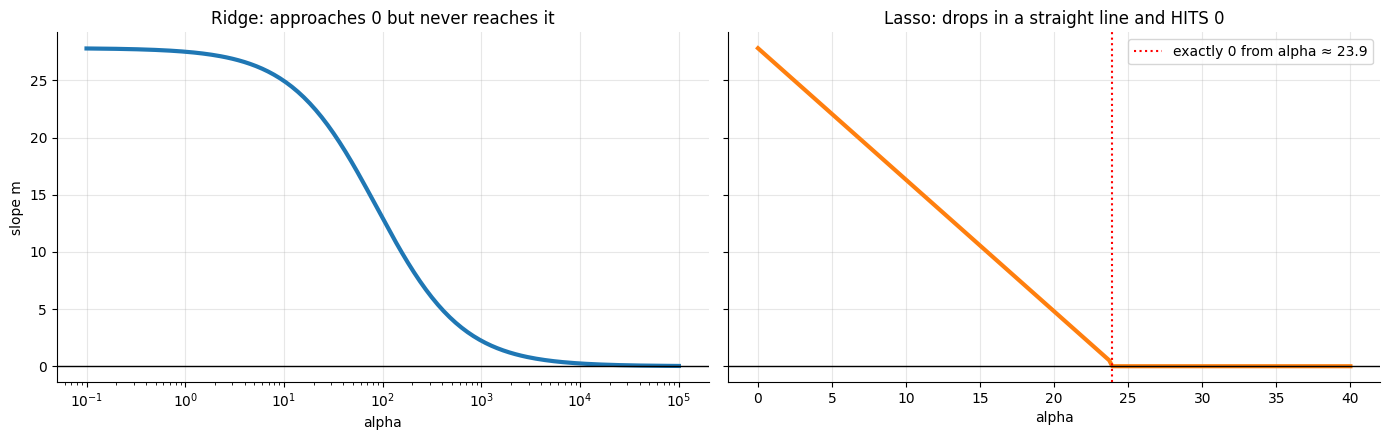

In [3]:
ridge_alphas = np.logspace(-1, 5, 200)
lasso_alphas = np.linspace(0.01, 40, 200)
ridge_slopes = [Ridge(alpha=a).fit(X1, y1).coef_[0] for a in ridge_alphas]
lasso_slopes = [Lasso(alpha=a).fit(X1, y1).coef_[0] for a in lasso_alphas]

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5), sharey=True)
axes[0].plot(ridge_alphas, ridge_slopes, linewidth=3, color='tab:blue')
axes[0].set_xscale('log')
axes[0].set_title('Ridge: approaches 0 but never reaches it')
axes[1].plot(lasso_alphas, lasso_slopes, linewidth=3, color='tab:orange')
zero_at = lasso_alphas[np.argmax(np.array(lasso_slopes) == 0)]
axes[1].axvline(zero_at, color='red', linestyle=':', label=f'exactly 0 from alpha ≈ {zero_at:.1f}')
axes[1].set_title('Lasso: drops in a straight line and HITS 0')
axes[1].legend()
for ax in axes:
    ax.axhline(0, color='black', linewidth=1)
    ax.set_xlabel('alpha')
axes[0].set_ylabel('slope m')
plt.tight_layout()
plt.show()

This is the single most important picture of the day:
- **Ridge** curves toward 0 forever: an *asymptote*.
- **Lasso** decreases at a constant rate and then **stops at exactly 0**.

> Note: sklearn scales the two losses differently (Lasso divides the error by $2n$), so the α values are **not** comparable between Ridge and Lasso. Only the shapes are.

---
## 3. 🏥 Lasso picks the important features for you

In [4]:
from sklearn.datasets import load_diabetes

X, y = load_diabetes(return_X_y=True, as_frame=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)
features = X.columns
print(X.shape)
X.head()

(442, 10)


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


**Diabetes dataset:** 442 patients, 10 features (age, sex, BMI, blood pressure, six blood measurements `s1`–`s6`),
target = disease progression after one year. The features are **already standardised** by scikit-learn. With your own data,
always scale first, because the penalty treats all coefficients equally (see `theory.md`).

> ✍️ **Core code: learn this.** Fit Lasso for several α and count how many features survive.

In [5]:
rows = []
for alpha in [0.01, 0.1, 0.5, 1, 2]:
    model = Lasso(alpha=alpha).fit(X_train, y_train)
    kept = features[model.coef_ != 0]
    rows.append({'alpha': alpha,
                 'test R²': round(r2_score(y_test, model.predict(X_test)), 3),
                 'features kept': len(kept),
                 'which ones': ', '.join(kept)})
pd.DataFrame(rows)

,alpha,test R²,features kept,which ones
0,0.01,0.441,10,"age, sex, bmi, bp, s1, s2, s3, s4, s5, s6"
1,0.10,0.433,7,"sex, bmi, bp, s1, s3, s5, s6"
2,0.50,0.389,4,"bmi, bp, s3, s5"
3,1.00,0.326,3,"bmi, bp, s5"
4,2.00,0.057,2,"bmi, s5"


As α grows, Lasso **fires features one by one**. The last ones standing, **`bmi`** and **`s5`**, are the strongest
predictors of diabetes progression. Lasso discovered this without being told.

There is a price: drop too many features and R² falls. So which α? Let cross-validation decide.

> ✍️ **Core code: learn this.** `LassoCV` = Lasso + automatic α search with k-fold cross-validation.

In [6]:
from sklearn.linear_model import LassoCV

lasso_cv = LassoCV(cv=5, random_state=0).fit(X_train, y_train)

print("Best alpha     :", round(lasso_cv.alpha_, 4))
print("Test R²        :", round(r2_score(y_test, lasso_cv.predict(X_test)), 3))
print("Features kept  :", list(features[lasso_cv.coef_ != 0]))
print("Features removed:", list(features[lasso_cv.coef_ == 0]))

Best alpha     : 0.0541
Test R²        : 0.438
Features kept  : ['sex', 'bmi', 'bp', 's1', 's3', 's5', 's6']
Features removed: ['age', 's2', 's4']


> 🎨 **Visualization only. You do not need to learn this code.** It just draws the picture below. Run it and focus on the plot. *(The code is collapsed; click it to expand if you are curious.)*

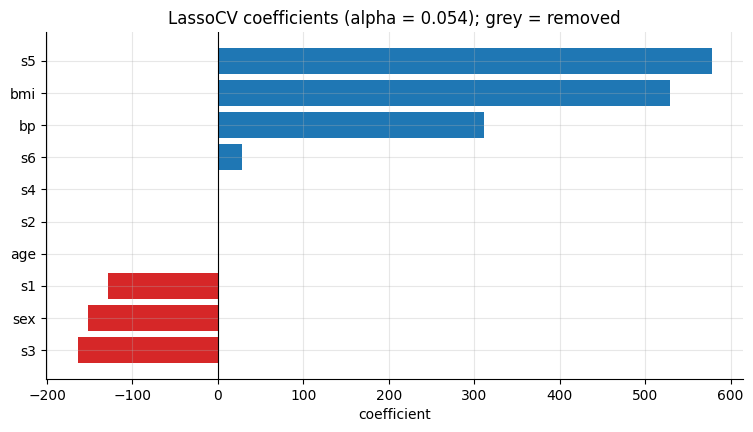

In [7]:
coef = pd.Series(lasso_cv.coef_, index=features).sort_values()
colors = ['lightgray' if c == 0 else ('tab:blue' if c > 0 else 'tab:red') for c in coef]
plt.figure(figsize=(9, 4.5))
plt.barh(coef.index, coef.values, color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title(f'LassoCV coefficients (alpha = {lasso_cv.alpha_:.3f}); grey = removed')
plt.xlabel('coefficient')
plt.show()

The model keeps nearly the same accuracy as Linear Regression while using **fewer features**: simpler, cheaper,
and easier to explain.

---
## 4. 🌊 Lasso on a wiggly polynomial

A degree-15 polynomial has 15 features ($x, x^2, \dots, x^{15}$). How many does Lasso keep?

> 🎨 **Visualization only. You do not need to learn this code.** It just draws the picture below. Run it and focus on the plot. *(The code is collapsed; click it to expand if you are curious.)*

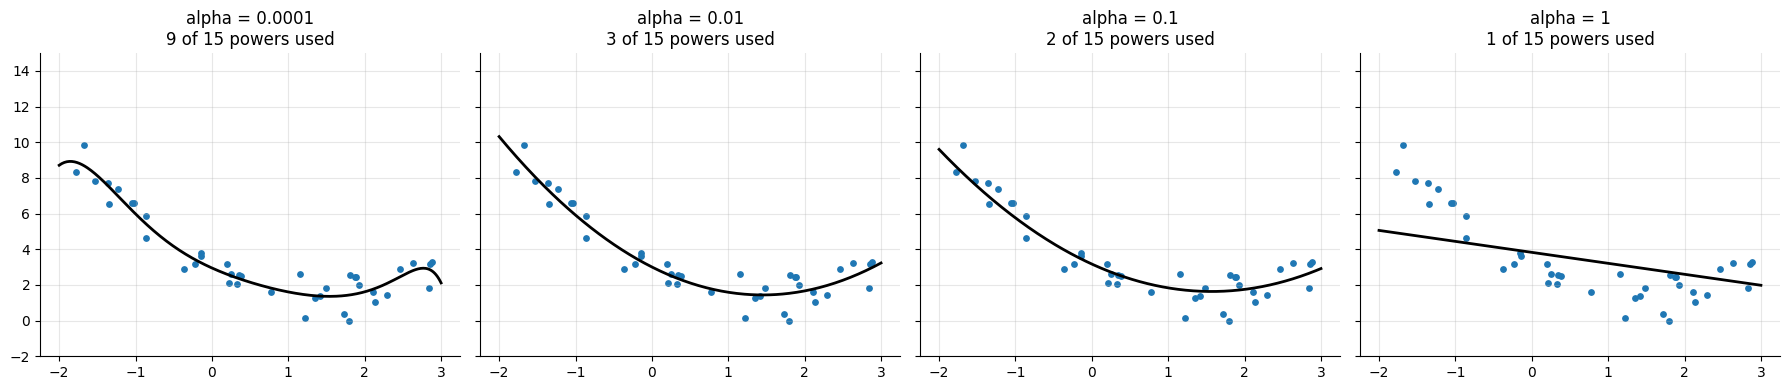

In [8]:
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings('ignore', category=ConvergenceWarning)
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

rng = np.random.default_rng(42)
x = rng.uniform(-2, 3, 40)
yp = 0.7 * x**2 - 2 * x + 3 + rng.normal(0, 1, 40)
grid = np.linspace(-2, 3, 300).reshape(-1, 1)

fig, axes = plt.subplots(1, 4, figsize=(18, 4), sharey=True)
for ax, alpha in zip(axes, [0.0001, 0.01, 0.1, 1]):
    model = make_pipeline(PolynomialFeatures(15, include_bias=False), StandardScaler(),
                          Lasso(alpha=alpha, max_iter=100000))
    model.fit(x.reshape(-1, 1), yp)
    n_used = np.sum(model[-1].coef_ != 0)
    ax.scatter(x, yp, s=15)
    ax.plot(grid, model.predict(grid), color='black', linewidth=2)
    ax.set_ylim(-2, 15)
    ax.set_title(f'alpha = {alpha}\n{n_used} of 15 powers used')
plt.tight_layout()
plt.show()

As α grows, Lasso switches off most of the 15 powers and keeps a few, giving a smooth curve. Push α too far and
even the useful ones go, leaving an underfit curve.

---
## 🧠 Quick check

<details><summary>1. What is the only difference between the Ridge and Lasso penalties?</summary>

Ridge uses $w^2$ (L2), Lasso uses $|w|$ (L1).
</details>

<details><summary>2. What can Lasso do that Ridge cannot?</summary>

Set coefficients to **exactly 0**, which is automatic feature selection.
</details>

<details><summary>3. All Lasso coefficients are 0. What does the model predict?</summary>

The intercept only, i.e. the mean of y for every input.
</details>

➡️ **Next:** `02-lasso-key-understandings.ipynb`: *why* the absolute value creates zeros, explained in pictures.